# Principal Component Analysis

## Breast cancer prediction

Breast cancer data has a large number (30) of features. 

Here we use PCA to identify the most significant patterns in the data and project it onto a lower dimensional space, preserving the key information while reducing complexity.

Using PCA we will reduce the number of dimension from **30 to 10**.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from time import perf_counter
plt.style.use('dark_background')
# matplotlib.rcParams['figure.dpi'] = 300

# Load the data

In [64]:
df = pd.read_csv("data_breast_cancer.csv")
# df = pd.read_csv("https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_breast_cancer.csv")

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [65]:
print(df.head(5)) # first 5 records

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [66]:
print(f"shape: {df.shape}") # (rows,columns)

## Observation: The data has 31 columns/features/dimensions

shape: (569, 31)


In [67]:
# 1) Count total duplicate rows: None 
df.duplicated().sum()

0

In [68]:
# 2) View the actual duplicate rows
df[df.duplicated(keep=False)]

# # Drop duplicates in-place without creating a new variable
# df.drop_duplicates(inplace=True)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target


In [69]:
# Check for missing values

df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

target
1    357
0    212
Name: count, dtype: int64


<Axes: xlabel='target'>

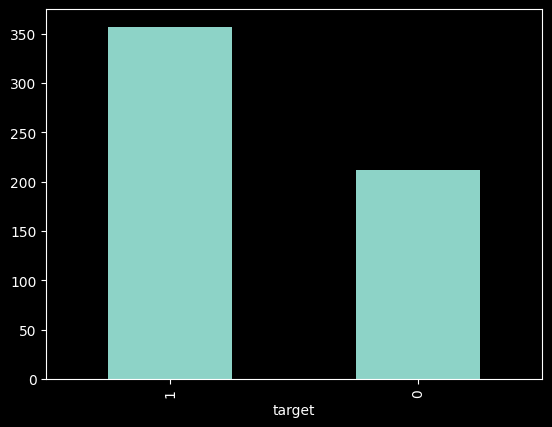

In [71]:
# Count unique values and plot as a bar chart
print(df['target'].value_counts())
df['target'].value_counts().plot(kind='bar')

# Observation: Mildly imbalanced

# Seperate features and target

In [72]:
# Extract X (independent variables/features). We apply PCA technique to this feature space.
X = df.drop(columns=["target"]).values  # Convert to numpy.ndarray

# Extract y (target variable)
y = df["target"].values  # Convert to numpy.ndarray

#Lets print first 2 records with their labels
print(X[:2])  
print(y[:2])  

[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]]
[0 0]


# Split data


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
     stratify=y,       
)


#  PCA 
Now lets apply PCA 

## Step1: Standardize

**First step in PCA is to standardize the dataset**

In [74]:
# Standardize the dataset for PCA
scaler = StandardScaler()

# scaler.fitX_train)   
# X_scaled = scaler.transform(X_train)

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [75]:
# Lets look at first 2 records. Here mean is 0 and std dev is 1.

print(f"First 2 records: \n{X_train_scaled[:2]}")

First 2 records: 
[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.49654896e-01  1.17859444e+00  1.54991557e+00
   1.91077868e-01 -1.73

In [76]:
# Mean of column ~ 0

np.mean(X_train_scaled, axis=0)

array([-4.31742554e-15,  2.24606658e-15, -7.38359313e-16,  1.71779562e-16,
        5.22695440e-15, -2.78897784e-15, -7.17008870e-16,  6.03180509e-16,
       -3.24837837e-15, -3.01370650e-15,  6.26360990e-16, -1.20587301e-15,
        6.19772853e-16, -5.77559978e-16, -1.69168708e-15,  1.49026091e-15,
        4.95757281e-16,  5.20462794e-16,  5.82196074e-16,  9.93100596e-17,
        3.95776208e-16,  5.67702173e-15, -2.39173760e-15, -1.00212878e-15,
        4.17010748e-15, -5.41203224e-16, -6.45759392e-16, -4.38721099e-16,
       -1.02286921e-15, -2.09063536e-15])

In [77]:
# Std of column ~ 1

np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Step2: Find the variance of each principal component

In [78]:
# 1) Perform PCA to get explained variance

# Fit PCA only on training data
pca = PCA()

# Fit PCA only on training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data
X_test_pca = pca.transform(X_test_scaled)

# Print the explained variance for all 30 components
explained_variance_ratio = np.round(pca.explained_variance_ratio_,3)
print(explained_variance_ratio)

[0.444 0.189 0.095 0.067 0.055 0.039 0.022 0.016 0.013 0.011 0.009 0.008
 0.008 0.005 0.003 0.003 0.002 0.002 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.    0.    0.    0.    0.   ]


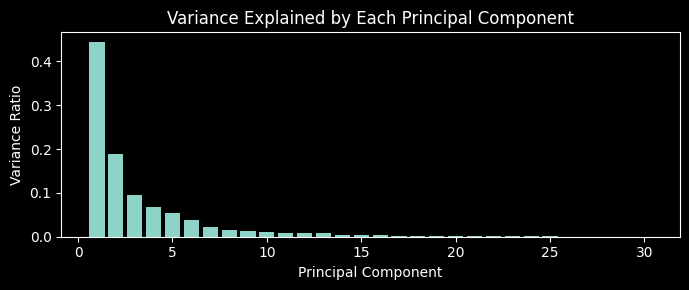

In [79]:
# 2) Visualize using bar plot
plt.figure(figsize=(7, 3))

plt.bar(range(1, len(explained_variance_ratio) + 1),
        explained_variance_ratio
)

plt.title("Variance Explained by Each Principal Component", color='white')
plt.xlabel("Principal Component", color='white')
plt.ylabel("Variance Ratio", color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

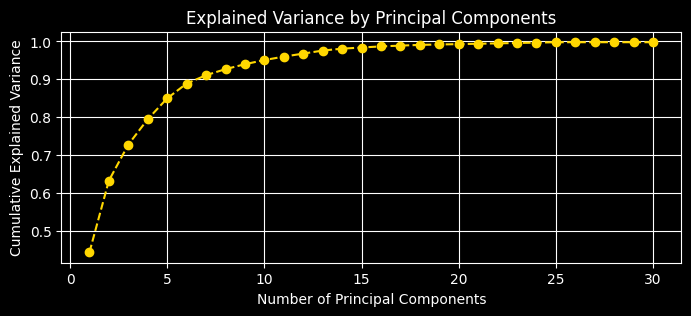

[0.444 0.633 0.728 0.795 0.85  0.889 0.911 0.927 0.94  0.951 0.96  0.968
 0.976 0.981 0.984 0.987 0.989 0.991 0.992 0.993 0.994 0.995 0.996 0.997
 0.998 0.998 0.998 0.998 0.998 0.998]


In [80]:
# 3) Now lets plot the cumulative sum

plt.figure(figsize=(8, 3))

plt.plot(range(1, len(explained_variance_ratio) + 1), 
         explained_variance_ratio.cumsum(),
         marker='o', 
         linestyle='--', 
         color='gold'
)

plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

print(explained_variance_ratio.cumsum()) # print cumulative sum

## Step3: Identify the number of components you need
**10 components seem to be a good number. It explains about 95% of variance.**

# Now going forward, we work with this 10 PC

In [81]:
pca_10d = PCA(n_components=10)

# Apply PCA to scaled data and retrieve 10 PC
X_train_pca_10d = pca_10d.fit_transform(X_train_scaled)

# Do the same to test data
X_test_pca_10d = pca_10d.transform(X_test_scaled)

In [82]:
# Lets look at one data point, say the first one

print("The original data point in 30 dimension:\n", X_train[0],"\n")
print("The scaled data point in 30 dimension  :\n", X_train_scaled[0],"\n")
print("The new data point in 10 dimension     :\n", X_train_pca_10d[0]) # it has 10 features/dimensions

The original data point in 30 dimension:
 [1.032e+01 1.635e+01 6.531e+01 3.249e+02 9.434e-02 4.994e-02 1.012e-02
 5.495e-03 1.885e-01 6.201e-02 2.104e-01 9.670e-01 1.356e+00 1.297e+01
 7.086e-03 7.247e-03 1.012e-02 5.495e-03 1.560e-02 2.606e-03 1.125e+01
 2.177e+01 7.112e+01 3.849e+02 1.285e-01 8.842e-02 4.384e-02 2.381e-02
 2.681e-01 7.399e-02] 

The scaled data point in 30 dimension  :
 [-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
 -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
  2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
 -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
 -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
 -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
 -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
 -3.52658049e-01 -5.41380026e-01] 

The new data point in 10 dimension     :
 [-4.16725097  0.25551153 -0.35231281  0.6479033  -0.64338351 -0.1062928
  0

# Now we compare results with PCA and without PCA

# A) Model with PCA

In [83]:
# 1)
model_with_pca = RandomForestClassifier(random_state=42,
                                        class_weight='balanced'
)

# Start timer
start_time = perf_counter()
model_with_pca.fit(X_train_pca_10d, y_train)
end_time = perf_counter()

print("Training Time WITH PCA:", end_time - start_time, "seconds")

y_pred_with_pca = model_with_pca.predict(X_test_pca_10d)

Training Time WITH PCA: 0.24002259992994368 seconds


In [84]:
# 2) Compare actual / predict for first 20

print("actual :", y_test[:20])
print("predict:", y_pred_with_pca[:20])

actual : [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]
predict: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [85]:
# 3) 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("WITH PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_with_pca))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_with_pca))

print("\nClassification Report")
print(classification_report(y_test, y_pred_with_pca))

WITH PCA
Accuracy: 0.9210526315789473

Confusion Matrix
[[38  4]
 [ 5 67]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        42
           1       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



### 92% Accuracy with PCA

# B) Model without PCA

In [86]:
# 1) 

model_without_pca = RandomForestClassifier(random_state=42,
                                          class_weight='balanced'
)

# Start timer
start_time = perf_counter()
model_without_pca.fit(X_train, y_train)
end_time = perf_counter()

print("Training Time WITHOUT PCA:", end_time - start_time, "seconds")


y_pred_without_pca = model_without_pca.predict(X_test)

Training Time WITHOUT PCA: 0.3050575000233948 seconds


In [87]:
# 2) 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("WITHOUT PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_without_pca))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_without_pca))

print("\nClassification Report")
print(classification_report(y_test, y_pred_without_pca))

WITHOUT PCA
Accuracy: 0.9473684210526315

Confusion Matrix
[[39  3]
 [ 3 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### 95% Accuracy without PCA

---

# Interpretation of Results

| Model       | Accuracy |
| ----------- | -------- |
| Without PCA | 95%      |
| With PCA    | 92%      |

This means:

* The original dataset performed slightly better.
* PCA reduced dimensionality but lost a small amount of information.
* Even after reducing dimensions, the model still performed very well.

---

# What PCA Did Here

PCA transformed the original features into a smaller set of principal components.

Instead of using all original variables:

* radius
* texture
* perimeter
* smoothness
* etc.

the model used:
$$
[
PC_1,  PC_2,  PC_3,  \dots,  PC_{10}
]
$$
These components capture **maximum variance** in the data.

## The model with PCA 
- train faster
- use less memory
- become computationally cheaper
